(60000, 28, 28, 1)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 784)                 │         101,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_2 (Reshape)                  │ (None, 28, 28, 1)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 114,064 (445.56 KB)

 Trainable params: 114,064 (445.56 KB)

...

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


epoch 1 | d loss: 0.6875635385513306 | g loss: 0.8525692224502563
epoch 2 | d loss: 0.7299284934997559 | g loss: 0.657461404800415
epoch 3 | d loss: 0.8291770219802856 | g loss: 0.5280056595802307
epoch 4 | d loss: 0.9497976899147034 | g loss: 0.4356585741043091
epoch 5 | d loss: 1.081695795059204 | g loss: 0.3660837411880493
epoch 6 | d loss: 1.2080296277999878 | g loss: 0.3137733042240143
epoch 7 | d loss: 1.3387048244476318 | g loss: 0.2743290960788727
epoch 8 | d loss: 1.4673781394958496 | g loss: 0.2426849901676178
epoch 9 | d loss: 1.5916213989257812 | g loss: 0.21738652884960175
epoch 10 | d loss: 1.710582971572876 | g loss: 0.19655518233776093
epoch 11 | d loss: 1.8244030475616455 | g loss: 0.17951659858226776
epoch 12 | d loss: 1.9289193153381348 | g loss: 0.1649850308895111
epoch 13 | d loss: 2.024430751800537 | g loss: 0.15257678925991058
epoch 14 | d loss: 2.1248533725738525 | g loss: 0.14191123843193054
epoch 15 | d loss: 2.2237040996551514 | g loss: 0.13263832032680511
ep

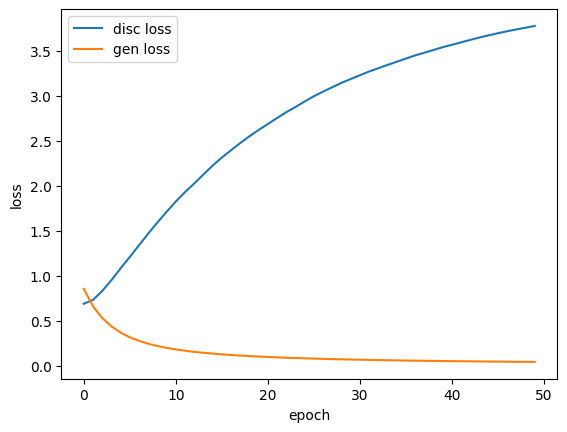

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


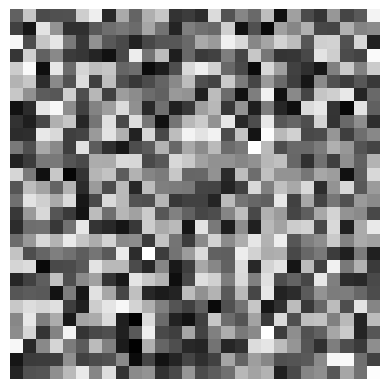

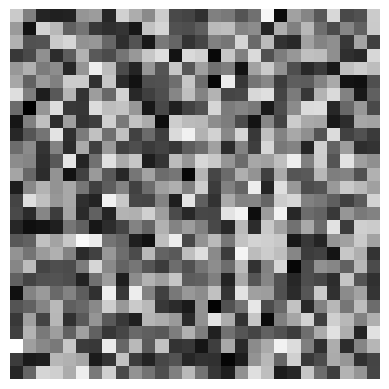

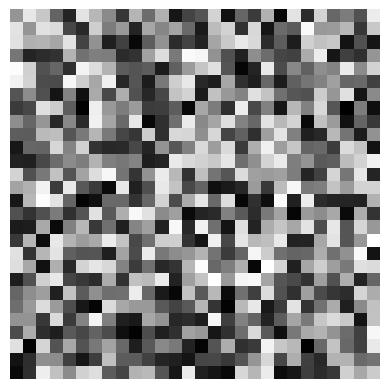

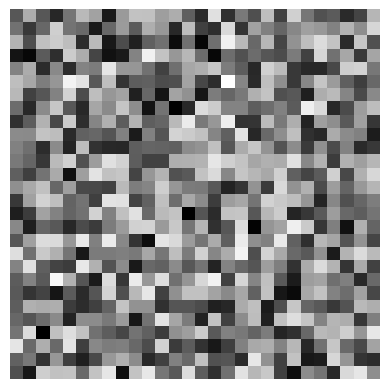

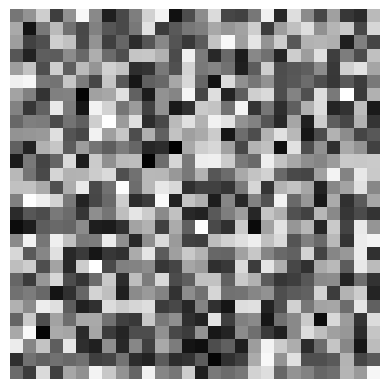

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Real Accuracy: [0.6810337901115417, 0.5899999737739563]
Fake Accuracy: [8.722509384155273, 0.0]


In [3]:
# gan on mnist
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

(x_train,_),(_,_)=mnist.load_data()

#normalize [-1,1]
x_train=(x_train.astype("float32")-127.5)/127.5
x_train=np.expand_dims(x_train, axis=-1)
print(x_train.shape)
#generator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Dense, Reshape

def gan():
    model=Sequential()
    model.add(Dense(128, input_dim=100))
    model.add(LeakyReLU())
    model.add(Dense(784, activation='tanh'))
    model.add(Reshape((28,28,1)))
    return model

gen=gan()
gen.summary()
#build discriminator

from tensorflow.keras.layers import Flatten

def discrim():
    model=Sequential()
    model.add(Flatten(input_shape=(28,28,1)))
    model.add(Dense(128))
    model.add(LeakyReLU())
    model.add(Dense(1,activation='sigmoid'))
    return model

disc=discrim()
disc.summary()
#compile

# compile discriminator FIRST
disc.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# freeze discriminator for GAN
disc.trainable = False

# build GAN
gan_model = Sequential([gen, disc])

# compile GAN
gan_model.compile(optimizer='adam', loss='binary_crossentropy')

#train

import matplotlib.pyplot as plt
epochs=50
batch_size=128
half_batch=batch_size//2

d_loss=[]
g_loss=[]

for e in range(epochs):
    idx=np.random.randint(0, x_train.shape[0], half_batch)
    real=x_train[idx]
    noise=np.random.normal(0,1,(half_batch, 100))
    fake=gen.predict(noise, verbose=0)
    d_loss_r=disc.train_on_batch(real, np.ones((half_batch,1)))
    d_loss_f=disc.train_on_batch(fake, np.zeros((half_batch,1)))   
    d = 0.5 * (d_loss_r[0] + d_loss_f[0])   # only loss

    noise=np.random.normal(0,1,(batch_size,100))
    g=float(gan_model.train_on_batch(noise, np.ones((batch_size,1))))

    d_loss.append(d)
    g_loss.append(g)
    print(f"epoch {e+1} | d loss: {d} | g loss: {g}")
plt.plot(d_loss)
plt.plot(g_loss)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(["disc loss", "gen loss"])
plt.show()
#generate

noise = np.random.normal(0,1,(5,100))
generated_imgs = gen.predict(noise)

# rescale back to [0,1]
generated_imgs = 0.5 * generated_imgs + 0.5

for i in range(5):
    plt.imshow(generated_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.show()

# evaluation of discriminator

# generate fake images
noise = np.random.normal(0,1,(100,100))
fake_imgs = gen.predict(noise)

# labels
real_labels = np.ones((100,1))
fake_labels = np.zeros((100,1))

# evaluate
d_loss_real = disc.evaluate(x_train[:100], real_labels, verbose=0)
d_loss_fake = disc.evaluate(fake_imgs, fake_labels, verbose=0)

print("Real Accuracy:", d_loss_real)
print("Fake Accuracy:", d_loss_fake)